## Download Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emineyetm/fake-news-detection-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-news-detection-datasets' dataset.
Path to dataset files: /kaggle/input/fake-news-detection-datasets


In [4]:
import os
filename = os.path.join(path,'News _dataset')

## Combine Fake + Real DataFrame

In [5]:
import pandas as pd

df1 = pd.read_csv(f'{filename}/Fake.csv')
df2 = pd.read_csv(f'{filename}/True.csv')

df1['fake'] = 1
df2['fake'] = 0

df = pd.concat([df1,df2])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   fake     44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


## Sample

In [7]:
df.sample(10)

,title,text,subject,date,fake
3562,WATCH: Reince Priebus Gives The Stupidest Rea...,"Reince Priebus, the soon-to-be ex-chairman of ...",News,"December 4, 2016",1
10692,Senate Republicans rule out action on Obama hi...,WASHINGTON (Reuters) - The Republican-led U.S....,politicsNews,"February 23, 2016",0
15347,UPDATE ON BEATING OF WHITE COP: BLACK MAN STEA...,UPDATE: AND SO IT BEGINS A police officer hold...,politics,"Aug 9, 2015",1
8743,Bush Once Apologized To China In Order To Fre...,"To hear conservatives, including those in the ...",News,"January 15, 2016",1
5523,"Republican VP Candidate Makes Trump Proud, Us...",Donald Trump is more than likely leaning towar...,News,"July 10, 2016",1
20191,"Juncker wants EU finance minister, no separate...","STRASBOURG, France (Reuters) - The European Un...",worldnews,"September 13, 2017",0
18870,HERE’S THE BEST WAY To Silence A Liberal Deman...,Here s a special public service announcement c...,left-news,"Apr 4, 2017",1
6020,Trump says illegal migrants brought as childre...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"January 26, 2017",0
4032,U.S. House may not kill debit card fee limits:...,WASHINGTON (Reuters) - The U.S. House banking ...,politicsNews,"April 27, 2017",0
3492,"GOP Gives Trump The Middle Finger, Prepares T...",Donald Trump may have decided that Russia is g...,News,"December 9, 2016",1


## combine - title + text + subject

In [8]:
df['combined'] = df['title'] + ' ' +df['text'] + ' ' +df['subject']
x = df['combined']
y = df['fake']

## Split training and Test set

In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,shuffle=True,test_size=0.3,random_state=42)

## Shape

In [30]:
print(f"training X shape: {x_train.shape}")
print(f"training Y shape: {y_train.shape}")
print("="*25)
print(f"test X shape: {x_test.shape}")
print(f"test Y shape: {y_test.shape}")

training X shape: (31428,)
training Y shape: (31428,)
test X shape: (13470,)
test Y shape: (13470,)


## Create Pipeline

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer,TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

clf1 = Pipeline([
    ('vec',CountVectorizer(stop_words='english',ngram_range=(1,2))),
    ('nb',MultinomialNB(alpha=0.01))
])

## Fit the training set

In [50]:
clf1.fit(x_train,y_train)

Pipeline(steps=[('vec',
                 CountVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('nb', MultinomialNB(alpha=0.01))])

## Accuracy

In [51]:
round(clf1.score(x_test,y_test),2)

0.98

## Few Mixed Examples

In [14]:
news = ["Stock market shows modest gains after positive corporate earnings reports",
        "Researchers publish peer-reviewed study on climate change impacts",
        "Federal reserve announces interest rate decision after committee meeting",
        "New medical guidelines recommend regular screening for early detection",
        "Government hiding aliens from public! Leaked documents reveal everything!",
        "100% free money from government! Claim yours now before it's too late!",
        "SHOCKING: World leaders are actually lizards! Mainstream media covering up!",
        "This one weird trick makes you rich overnight! Banks hate this!",
        "Ancient pyramid discovered on Mars! NASA photoshopped images to hide truth!"]

In [15]:
clf1.predict(news)

array([0, 1, 0, 0, 1, 1, 1, 1, 1])

In [16]:
y_pred = clf1.predict(x_test)

from sklearn.metrics import classification_report
print("classification report")
print(classification_report(y_test,y_pred,target_names=['fake','real']))

classification report
              precision    recall  f1-score   support

        fake       0.97      0.98      0.98      6379
        real       0.98      0.98      0.98      7091

    accuracy                           0.98     13470
   macro avg       0.98      0.98      0.98     13470
weighted avg       0.98      0.98      0.98     13470



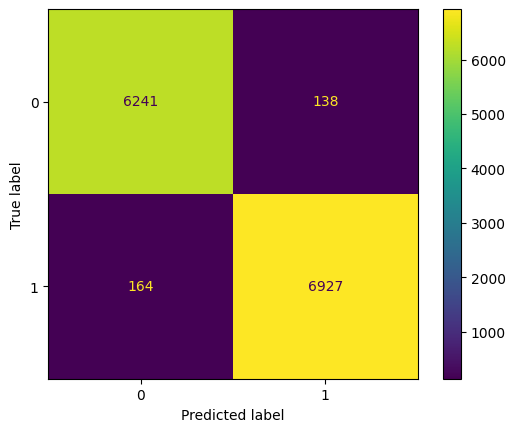

In [17]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

##  using countvectorizer + tfidtransformer with GridSearchCV

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

text_clf = Pipeline([

    ('vect', CountVectorizer(stop_words='english')),

    ('tfidf', TfidfTransformer()),

    ('clf', MultinomialNB()),

])

param_grid = {"vect__ngram_range": [(1, 1), (1, 2)],
              'tfidf__use_idf': (True, False),
              "clf__alpha":[0.1,0.5]}

gs_clf = GridSearchCV(text_clf, param_grid, cv=5, n_jobs=-1)

gs_clf.fit(x_train, y_train)


print(f'Best CV score: {gs_clf.best_score_:.1%}')

print(f'Best params: {gs_clf.best_params_}')

print(f'Test accuracy: {accuracy_score(y_test, gs_clf.predict(x_test)):.1%}')

Best CV score: 97.1%
Best params: {'clf__alpha': 0.1, 'tfidf__use_idf': True, 'vect__ngram_range': (1, 2)}
Test accuracy: 97.1%


In [46]:
gs_clf.predict(news)

array([0, 1, 0, 0, 1, 1, 1, 1, 1])

In [47]:
y_pred = gs_clf.predict(x_test)

In [48]:
from sklearn.metrics import classification_report
print("classification report")
print(classification_report(y_test,y_pred,target_names=['fake','real']))

classification report
              precision    recall  f1-score   support

        fake       0.97      0.97      0.97      6379
        real       0.97      0.97      0.97      7091

    accuracy                           0.97     13470
   macro avg       0.97      0.97      0.97     13470
weighted avg       0.97      0.97      0.97     13470



### Performance got degraded by 1%

## Export Model

In [24]:
import pickle

with open("fake_news_pipeline.pkl", "wb") as f:
    pickle.dump(clf1, f)  # saves vectorizer + model together automatically